In [7]:
# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# HuggingFace
from transformers import pipeline

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# ------------------------------------------
# Rutas
# ------------------------------------------
DATA_PATH = "/content/drive/MyDrive/Curso Especializacion/Proyecto/master_dataset_colab.csv"
RESULTS_DIR = "/content/drive/MyDrive/Curso Especializacion/Proyecto/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULTS_CSV = os.path.join(RESULTS_DIR, "day8_huggingface_results.csv")

In [10]:
# ==========================================
# 2. DEFINICIÓN DE NIVELES DE RIESGO
# ==========================================
RISK_LEVELS = {
    'bueno': {'min': 0, 'max': 12.0, 'color': '#2ecc71', 'emoji': '🟢'},
    'moderado': {'min': 12.1, 'max': 35.4, 'color': '#f39c12', 'emoji': '🟡'},
    'malo': {'min': 35.5, 'max': 55.4, 'color': '#e67e22', 'emoji': '🟠'},
    'peligroso': {'min': 55.5, 'max': float('inf'), 'color': '#e74c3c', 'emoji': '🔴'},
}

def classify_risk(pm25_value):
    """Clasifica un valor de PM2.5 en nivel de riesgo."""
    if pm25_value <= 12.0:
        return 'bueno'
    elif pm25_value <= 35.4:
        return 'moderado'
    elif pm25_value <= 55.4:
        return 'malo'
    else:
        return 'peligroso'


def generate_risk_description(pm25_value, risk_level, station=None):
    """Genera una descripción textual del nivel de riesgo."""
    info = RISK_LEVELS[risk_level]
    location = f" en {station}" if station else ""
    descriptions = {
        'bueno': f"La calidad del aire{location} es BUENA. PM2.5: {pm25_value:.1f} µg/m³. No se requieren precauciones especiales.",
        'moderado': f"La calidad del aire{location} es MODERADA. PM2.5: {pm25_value:.1f} µg/m³. Personas sensibles deben limitar actividad exterior prolongada.",
        'malo': f"La calidad del aire{location} es MALA. PM2.5: {pm25_value:.1f} µg/m³. Se recomienda reducir actividades al aire libre. Grupos sensibles deben permanecer en interiores.",
        'peligroso': f"⚠️ ALERTA: La calidad del aire{location} es PELIGROSA. PM2.5: {pm25_value:.1f} µg/m³. Evitar toda actividad al aire libre. Cerrar ventanas.",
    }
    return descriptions[risk_level]


📂 Cargando datos...
  Shape: (195183, 22)

📊 Distribución de niveles de riesgo:
  🟢 bueno       :  129750 (66.5%)
  🟡 moderado    :   59508 (30.5%)
  🟠 malo        :    5050 (2.6%)
  🔴 peligroso   :     875 (0.4%)


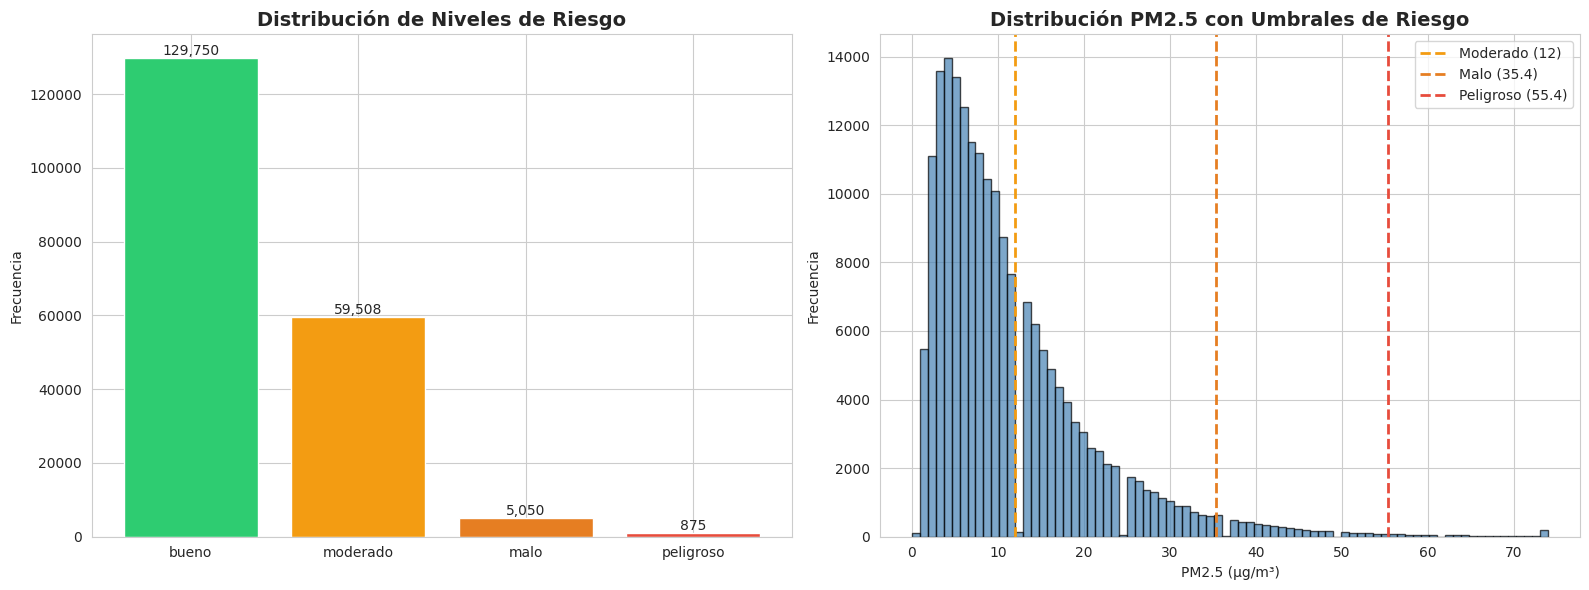

In [11]:
# ==========================================
# 3. CARGA Y PREPARACIÓN DE DATOS
# ==========================================
print("\n📂 Cargando datos...")
df = pd.read_csv(DATA_PATH)
print(f"  Shape: {df.shape}")

# Crear etiqueta de riesgo
df['risk_level'] = df['pm25'].apply(classify_risk)

# Distribución de clases
print("\n📊 Distribución de niveles de riesgo:")
risk_counts = df['risk_level'].value_counts()
for level, count in risk_counts.items():
    info = RISK_LEVELS[level]
    pct = count / len(df) * 100
    print(f"  {info['emoji']} {level:12s}: {count:7d} ({pct:.1f}%)")

# Visualización de distribución
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras
colors = [RISK_LEVELS[l]['color'] for l in ['bueno', 'moderado', 'malo', 'peligroso']]
order = ['bueno', 'moderado', 'malo', 'peligroso']
present_levels = [l for l in order if l in risk_counts.index]
present_colors = [RISK_LEVELS[l]['color'] for l in present_levels]

ax = axes[0]
bars = ax.bar(present_levels, [risk_counts[l] for l in present_levels], color=present_colors)
ax.set_title('Distribución de Niveles de Riesgo', fontsize=14, fontweight='bold')
ax.set_ylabel('Frecuencia')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{int(height):,}', ha='center', va='bottom', fontsize=10)

# Histograma PM2.5 con zonas de riesgo
ax = axes[1]
ax.hist(df['pm25'], bins=80, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(x=12.0, color='#f39c12', linestyle='--', linewidth=2, label='Moderado (12)')
ax.axvline(x=35.4, color='#e67e22', linestyle='--', linewidth=2, label='Malo (35.4)')
ax.axvline(x=55.4, color='#e74c3c', linestyle='--', linewidth=2, label='Peligroso (55.4)')
ax.set_title('Distribución PM2.5 con Umbrales de Riesgo', fontsize=14, fontweight='bold')
ax.set_xlabel('PM2.5 (µg/m³)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
dist_path = os.path.join(RESULTS_DIR, "day8_risk_distribution.png")
plt.savefig(dist_path, dpi=150, bbox_inches='tight')
plt.show()

In [12]:
df['fecha'] = pd.to_datetime(df['fecha'])
# Eliminar la columna 'fecha' antes de pasar al modelo, ya que ya tenemos características de tiempo numéricas
df = df.drop(columns=['fecha'])
print(f"Columnas después de eliminar 'fecha': {list(df.columns)}")
print(f"Tipos de datos actualizados:\n{df.dtypes}")

Columnas después de eliminar 'fecha': ['pm25', 'no2', 'o3', 'temperatura', 'velocidad_viento', 'precipitacion', 'humedad_relativa', 'hora_del_dia', 'dia_de_la_semana', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_rolling_6h', 'station_name', 'station_Francia', 'station_Molí del Sol', 'station_Pista de Silla', 'station_Puerto Moll Trans. Ponent', 'station_Puerto Valencia', 'station_Puerto llit antic Túria', 'station_Universidad Politécnica', 'risk_level']
Tipos de datos actualizados:
pm25                                 float64
no2                                  float64
o3                                   float64
temperatura                          float64
velocidad_viento                     float64
precipitacion                        float64
humedad_relativa                     float64
hora_del_dia                           int64
dia_de_la_semana                       int64
pm25_lag1                            float64
pm25_lag2                            float64
pm25_lag3        

In [13]:
# ==========================================
# 4. CLASIFICADOR BASADO EN FEATURES (ML)
# ==========================================
print("\n" + "="*60)
print("🔄 Entrenando clasificadores ML")
print("="*60)

# Preparar features
feature_cols = [c for c in df.columns if c not in ['station_name', 'pm25', 'risk_level']]
X = df[feature_cols].values
y_labels = df['risk_level'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_
n_classes = len(class_names)

print(f"  Features: {len(feature_cols)}")
print(f"  Clases: {list(class_names)}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)

# Normalizar
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4.1 Random Forest ---
print("\n  📌 Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"     Accuracy: {acc_rf:.4f}")
print(f"     F1 (weighted): {f1_rf:.4f}")

# --- 4.2 Gradient Boosting ---
print("\n  📌 Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=SEED, max_depth=5)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')
print(f"     Accuracy: {acc_gb:.4f}")
print(f"     F1 (weighted): {f1_gb:.4f}")

# --- 4.3 Red Neuronal (Dense) ---
print("\n  📌 Red Neuronal Dense...")
y_train_cat = to_categorical(y_train, n_classes)
y_test_cat = to_categorical(y_test, n_classes)

nn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])
nn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy',
                 metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
nn_model.fit(X_train_scaled, y_train_cat, epochs=50, batch_size=128,
             validation_split=0.15, callbacks=[early_stop], verbose=0)

y_pred_nn_prob = nn_model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)
acc_nn = accuracy_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn, average='weighted')
print(f"     Accuracy: {acc_nn:.4f}")
print(f"     F1 (weighted): {f1_nn:.4f}")


🔄 Entrenando clasificadores ML
  Features: 19
  Clases: ['bueno', 'malo', 'moderado', 'peligroso']

  📌 Random Forest...
     Accuracy: 0.8932
     F1 (weighted): 0.8919

  📌 Gradient Boosting...
     Accuracy: 0.8954
     F1 (weighted): 0.8946

  📌 Red Neuronal Dense...
1220/1220 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
     Accuracy: 0.8956
     F1 (weighted): 0.8950


In [14]:
# ==========================================
# 5. HUGGINGFACE ZERO-SHOT CLASSIFICATION
# ==========================================
print("\n" + "="*60)
print("🤗 HuggingFace Zero-Shot Classification")
print("="*60)

# Usar pipeline de zero-shot para clasificar descripciones textuales
print("  Cargando modelo zero-shot...")
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

candidate_labels = ["buena calidad del aire", "calidad del aire moderada",
                    "mala calidad del aire", "calidad del aire peligrosa"]

# Probar con ejemplos representativos
test_descriptions = [
    "La concentración de partículas finas PM2.5 es de 5 microgramos por metro cúbico",
    "La concentración de partículas finas PM2.5 es de 25 microgramos por metro cúbico",
    "La concentración de partículas finas PM2.5 es de 45 microgramos por metro cúbico",
    "La concentración de partículas finas PM2.5 es de 80 microgramos por metro cúbico",
]

print("\n  📊 Resultados Zero-Shot:")
zs_results = []
for desc in test_descriptions:
    result = zero_shot(desc, candidate_labels)
    best_label = result['labels'][0]
    best_score = result['scores'][0]
    print(f"\n  Input: {desc}")
    print(f"  → {best_label} (confianza: {best_score:.3f})")
    for label, score in zip(result['labels'], result['scores']):
        print(f"    {label}: {score:.3f}")
    zs_results.append({
        'description': desc,
        'predicted': best_label,
        'confidence': round(best_score, 3)
    })


🤗 HuggingFace Zero-Shot Classification
  Cargando modelo zero-shot...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


  📊 Resultados Zero-Shot:

  Input: La concentración de partículas finas PM2.5 es de 5 microgramos por metro cúbico
  → calidad del aire peligrosa (confianza: 0.462)
    calidad del aire peligrosa: 0.462
    mala calidad del aire: 0.210
    calidad del aire moderada: 0.183
    buena calidad del aire: 0.145

  Input: La concentración de partículas finas PM2.5 es de 25 microgramos por metro cúbico
  → calidad del aire peligrosa (confianza: 0.460)
    calidad del aire peligrosa: 0.460
    mala calidad del aire: 0.202
    calidad del aire moderada: 0.189
    buena calidad del aire: 0.149

  Input: La concentración de partículas finas PM2.5 es de 45 microgramos por metro cúbico
  → calidad del aire peligrosa (confianza: 0.457)
    calidad del aire peligrosa: 0.457
    mala calidad del aire: 0.210
    calidad del aire moderada: 0.183
    buena calidad del aire: 0.150

  Input: La concentración de partículas finas PM2.5 es de 80 microgramos por metro cúbico
  → calidad del aire peligrosa (co


📊 Evaluación Detallada — Mejor Clasificador

  🏆 Mejor clasificador: Red Neuronal
     Accuracy: 0.8956
     F1 (weighted): 0.8950

  Reporte de clasificación (Red Neuronal):
              precision    recall  f1-score   support

       bueno       0.93      0.94      0.94     25950
        malo       0.68      0.59      0.63      1010
    moderado       0.83      0.84      0.83     11902
   peligroso       0.70      0.58      0.63       175

    accuracy                           0.90     39037
   macro avg       0.79      0.73      0.76     39037
weighted avg       0.89      0.90      0.90     39037



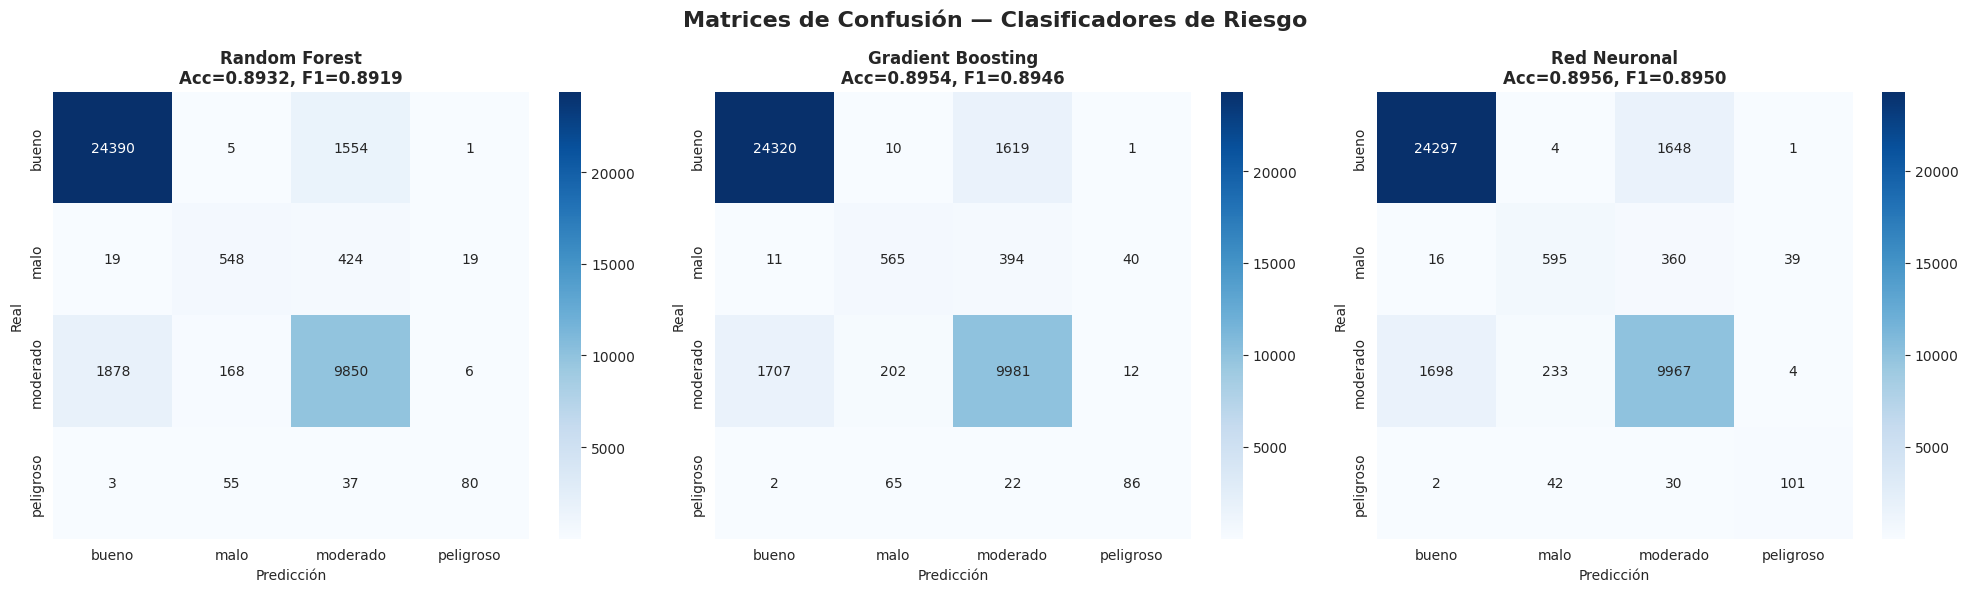

✅ Matrices de confusión guardadas en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day8_confusion_matrices.png


In [15]:
# ==========================================
# 6. MATRIZ DE CONFUSIÓN Y REPORTE
# ==========================================
print("\n" + "="*60)
print("📊 Evaluación Detallada — Mejor Clasificador")
print("="*60)

# Seleccionar el mejor clasificador ML
classifiers = {
    'Random Forest': (y_pred_rf, acc_rf, f1_rf),
    'Gradient Boosting': (y_pred_gb, acc_gb, f1_gb),
    'Red Neuronal': (y_pred_nn, acc_nn, f1_nn),
}
best_clf_name = max(classifiers, key=lambda k: classifiers[k][1])
best_preds, best_acc, best_f1 = classifiers[best_clf_name]

print(f"\n  🏆 Mejor clasificador: {best_clf_name}")
print(f"     Accuracy: {best_acc:.4f}")
print(f"     F1 (weighted): {best_f1:.4f}")

# Classification report
print(f"\n  Reporte de clasificación ({best_clf_name}):")
print(classification_report(y_test, best_preds, target_names=class_names))

# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (clf_name, (preds, acc, f1)) in enumerate(classifiers.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{clf_name}\nAcc={acc:.4f}, F1={f1:.4f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.suptitle('Matrices de Confusión — Clasificadores de Riesgo', fontsize=16, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(RESULTS_DIR, "day8_confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Matrices de confusión guardadas en: {cm_path}")

In [16]:
# ==========================================
# 7. EJEMPLO DE GENERACIÓN DE ALERTAS
# ==========================================
print("\n" + "="*60)
print("📢 Ejemplos de Alertas Generadas")
print("="*60)

sample_values = [5.2, 18.7, 42.3, 68.5]
for val in sample_values:
    risk = classify_risk(val)
    info = RISK_LEVELS[risk]
    desc = generate_risk_description(val, risk, station="Valencia Viveros")
    print(f"\n  {info['emoji']} PM2.5 = {val} µg/m³ → {risk.upper()}")
    print(f"     {desc}")


📢 Ejemplos de Alertas Generadas

  🟢 PM2.5 = 5.2 µg/m³ → BUENO
     La calidad del aire en Valencia Viveros es BUENA. PM2.5: 5.2 µg/m³. No se requieren precauciones especiales.

  🟡 PM2.5 = 18.7 µg/m³ → MODERADO
     La calidad del aire en Valencia Viveros es MODERADA. PM2.5: 18.7 µg/m³. Personas sensibles deben limitar actividad exterior prolongada.

  🟠 PM2.5 = 42.3 µg/m³ → MALO
     La calidad del aire en Valencia Viveros es MALA. PM2.5: 42.3 µg/m³. Se recomienda reducir actividades al aire libre. Grupos sensibles deben permanecer en interiores.

  🔴 PM2.5 = 68.5 µg/m³ → PELIGROSO
     ⚠️ ALERTA: La calidad del aire en Valencia Viveros es PELIGROSA. PM2.5: 68.5 µg/m³. Evitar toda actividad al aire libre. Cerrar ventanas.


In [17]:
# ==========================================
# 8. GUARDAR RESULTADOS
# ==========================================
results = {
    'model': ['Random Forest', 'Gradient Boosting', 'Red Neuronal Dense'],
    'accuracy': [acc_rf, acc_gb, acc_nn],
    'f1_weighted': [f1_rf, f1_gb, f1_nn],
}
results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_CSV, index=False)
print(f"\n✅ Resultados guardados en: {RESULTS_CSV}")

# Guardar modelo NN
nn_model_path = os.path.join(RESULTS_DIR, "risk_classifier_nn.keras")
nn_model.save(nn_model_path)
print(f"✅ Modelo NN guardado en: {nn_model_path}")

# Guardar info de clases
class_info = {
    'classes': list(class_names),
    'risk_levels': RISK_LEVELS,
    'feature_columns': feature_cols,
    'best_classifier': best_clf_name,
    'best_accuracy': round(best_acc, 4),
    'best_f1': round(best_f1, 4),
}
info_path = os.path.join(RESULTS_DIR, "day8_class_info.json")
with open(info_path, 'w') as f:
    json.dump(class_info, f, indent=2, default=str)

print(f"✅ Info de clases guardada en: {info_path}")
print("\n🎯 Clasificación de riesgo completada.")


✅ Resultados guardados en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day8_huggingface_results.csv
✅ Modelo NN guardado en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/risk_classifier_nn.keras
✅ Info de clases guardada en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day8_class_info.json

🎯 Clasificación de riesgo completada.
